In [35]:
import random
import math

# -------- Simulated Annealing --------
def SA(func, bounds, max_iter=1000, initial_temp=1000, cooling_rate=0.95):
    def random_solution():
        return [random.uniform(low, high) for (low, high) in bounds]

    def neighbor(x):
        return [max(min(xi + random.uniform(-1, 1), bounds[i][1]), bounds[i][0])
                for i, xi in enumerate(x)]

    current = random_solution()
    current_eval = func(current)
    best = current[:]
    best_eval = current_eval
    temp = initial_temp

    for i in range(max_iter):
        candidate = neighbor(current)
        candidate_eval = func(candidate)
        delta = candidate_eval - current_eval

        if delta < 0 or math.exp(-delta / temp) > random.random():
            current, current_eval = candidate, candidate_eval
            if candidate_eval < best_eval:
                best, best_eval = candidate[:], candidate_eval

        temp *= cooling_rate

    print("SA Best:", best)
    print("SA Value:", best_eval)
    return best, best_eval

# -------- Particle Swarm Optimization --------
def PSO(func, bounds, max_iter=100, pop_size=30, w=0.5, c1=1.5, c2=1.5):
    dim = len(bounds)
    swarm = [([random.uniform(low, high) for (low, high) in bounds], [0]*dim)
             for _ in range(pop_size)]

    personal_best = [(pos[:], func(pos)) for pos, _ in swarm]
    global_best = min(personal_best, key=lambda x: x[1])

    for _ in range(max_iter):
        for i, (position, velocity) in enumerate(swarm):
            for d in range(dim):
                r1, r2 = random.random(), random.random()
                velocity[d] = (
                    w * velocity[d] +
                    c1 * r1 * (personal_best[i][0][d] - position[d]) +
                    c2 * r2 * (global_best[0][d] - position[d])
                )
                position[d] += velocity[d]
                position[d] = max(bounds[d][0], min(position[d], bounds[d][1]))
            value = func(position)
            if value < personal_best[i][1]:
                personal_best[i] = (position[:], value)
                if value < global_best[1]:
                    global_best = (position[:], value)

    print("PSO Best:", global_best[0])
    print("PSO Value:", global_best[1])
    return global_best

# -------- Teaching-Learning Based Optimization --------
def TLBO(func, bounds, max_iter=100, pop_size=30):
    dim = len(bounds)
    population = [[random.uniform(low, high) for (low, high) in bounds]
                  for _ in range(pop_size)]

    for _ in range(max_iter):
        fitness = [func(ind) for ind in population]
        teacher = population[fitness.index(min(fitness))]
        mean = [sum(x[i] for x in population) / pop_size for i in range(dim)]

        # Teacher Phase
        for i in range(pop_size):
            TF = random.choice([1, 2])
            new_ind = [x + random.random() * (t - TF * m)
                       for x, t, m in zip(population[i], teacher, mean)]
            new_ind = [max(bounds[d][0], min(new_ind[d], bounds[d][1])) for d in range(dim)]
            if func(new_ind) < func(population[i]):
                population[i] = new_ind

        # Learner Phase
        for i in range(pop_size):
            j = random.choice([x for x in range(pop_size) if x != i])
            if func(population[i]) < func(population[j]):
                diff = [x1 - x2 for x1, x2 in zip(population[i], population[j])]
            else:
                diff = [x2 - x1 for x1, x2 in zip(population[i], population[j])]
            new_ind = [x + random.random() * d for x, d in zip(population[i], diff)]
            new_ind = [max(bounds[d][0], min(new_ind[d], bounds[d][1])) for d in range(dim)]
            if func(new_ind) < func(population[i]):
                population[i] = new_ind

    best = min(population, key=func)
    print("TLBO Best:", best)
    print("TLBO Value:", func(best))
    return best, func(best)




In [36]:
# Sample function: (x0 - 1)^2 + (x1 + 2)^2 + x2^2 + sin(x3)
f = lambda x: (x[0] - 1)**2 + (x[1] + 2)**2 + x[2]**2 + math.sin(x[3])
bounds = [(-10, 10)] * 4

SA(f, bounds)
PSO(f, bounds)
TLBO(f, bounds)

SA Best: [0.9814858932114936, -1.77785910896711, 0.06909757440499109, -1.4835536894332118]
SA Value: -0.9417329519076054
PSO Best: [0.9999999979393238, -2.000000001805935, -1.6775043059333626e-10, 4.712388980691742]
PSO Value: -1.0
TLBO Best: [1.00000087832313, -2.0000020210272065, -2.2137049596882678e-07, -7.853980705632432]
TLBO Value: -0.9999999999946642


([1.00000087832313,
  -2.0000020210272065,
  -2.2137049596882678e-07,
  -7.853980705632432],
 -0.9999999999946642)

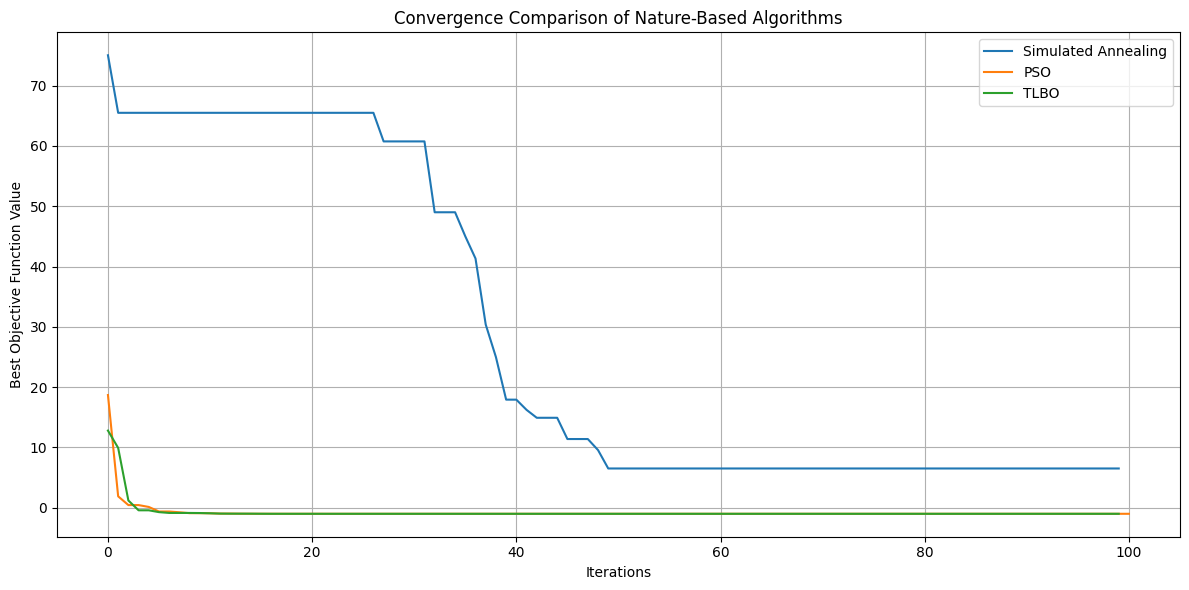

In [37]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
from time import time

# Objective function
def test_func(x):
    return (x[0] - 1)**2 + (x[1] + 2)**2 + x[2]**2 + math.sin(x[3])

# Bounds for variables
bounds = [(-10, 10)] * 4

# ------ SA -------
def SA(func, bounds, max_iter=100, initial_temp=1000, cooling_rate=0.95):
    history = []

    def random_solution():
        return [random.uniform(low, high) for (low, high) in bounds]

    def neighbor(x):
        return [max(min(xi + random.uniform(-1, 1), bounds[i][1]), bounds[i][0])
                for i, xi in enumerate(x)]

    current = random_solution()
    current_eval = func(current)
    best = current[:]
    best_eval = current_eval
    temp = initial_temp

    for _ in range(max_iter):
        candidate = neighbor(current)
        candidate_eval = func(candidate)
        if candidate_eval < best_eval:
            best = candidate[:]
            best_eval = candidate_eval
        history.append(best_eval)
        delta = candidate_eval - current_eval
        if delta < 0 or math.exp(-delta / temp) > random.random():
            current, current_eval = candidate, candidate_eval
        temp *= cooling_rate
    return best, best_eval, history

# ------ PSO -------
def PSO(func, bounds, max_iter=100, pop_size=30, w=0.5, c1=1.5, c2=1.5):
    dim = len(bounds)
    swarm = [([random.uniform(low, high) for (low, high) in bounds], [0]*dim)
             for _ in range(pop_size)]
    personal_best = [(pos[:], func(pos)) for pos, _ in swarm]
    global_best = min(personal_best, key=lambda x: x[1])
    history = [global_best[1]]

    for _ in range(max_iter):
        for i, (position, velocity) in enumerate(swarm):
            for d in range(dim):
                r1, r2 = random.random(), random.random()
                velocity[d] = (w * velocity[d] +
                               c1 * r1 * (personal_best[i][0][d] - position[d]) +
                               c2 * r2 * (global_best[0][d] - position[d]))
                position[d] += velocity[d]
                position[d] = max(bounds[d][0], min(position[d], bounds[d][1]))
            value = func(position)
            if value < personal_best[i][1]:
                personal_best[i] = (position[:], value)
                if value < global_best[1]:
                    global_best = (position[:], value)
        history.append(global_best[1])
    return global_best[0], global_best[1], history

# ------ TLBO -------
def TLBO(func, bounds, max_iter=100, pop_size=30):
    dim = len(bounds)
    population = [[random.uniform(low, high) for (low, high) in bounds] for _ in range(pop_size)]
    history = []

    for _ in range(max_iter):
        fitness = [func(ind) for ind in population]
        teacher = population[fitness.index(min(fitness))]
        mean = [sum(x[i] for x in population) / pop_size for i in range(dim)]
        for i in range(pop_size):
            TF = random.choice([1, 2])
            new_ind = [x + random.random() * (t - TF * m)
                       for x, t, m in zip(population[i], teacher, mean)]
            new_ind = [max(bounds[d][0], min(new_ind[d], bounds[d][1])) for d in range(dim)]
            if func(new_ind) < func(population[i]):
                population[i] = new_ind
        for i in range(pop_size):
            j = random.choice([x for x in range(pop_size) if x != i])
            diff = [population[i][d] - population[j][d]
                    if func(population[i]) < func(population[j])
                    else population[j][d] - population[i][d]
                    for d in range(dim)]
            new_ind = [x + random.random() * d for x, d in zip(population[i], diff)]
            new_ind = [max(bounds[d][0], min(new_ind[d], bounds[d][1])) for d in range(dim)]
            if func(new_ind) < func(population[i]):
                population[i] = new_ind
        history.append(min(func(ind) for ind in population))
    best = min(population, key=func)
    return best, func(best), history


# Run and collect histories
methods = [SA, PSO, TLBO]
labels = ["Simulated Annealing", "PSO", "TLBO"]
histories = []

for method in methods:
    best, value, history = method(test_func, bounds)
    histories.append(history)

# Plotting
plt.figure(figsize=(12, 6))
for label, hist in zip(labels, histories):
    plt.plot(hist, label=label)
plt.xlabel("Iterations")
plt.ylabel("Best Objective Function Value")
plt.title("Convergence Comparison of Nature-Based Algorithms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


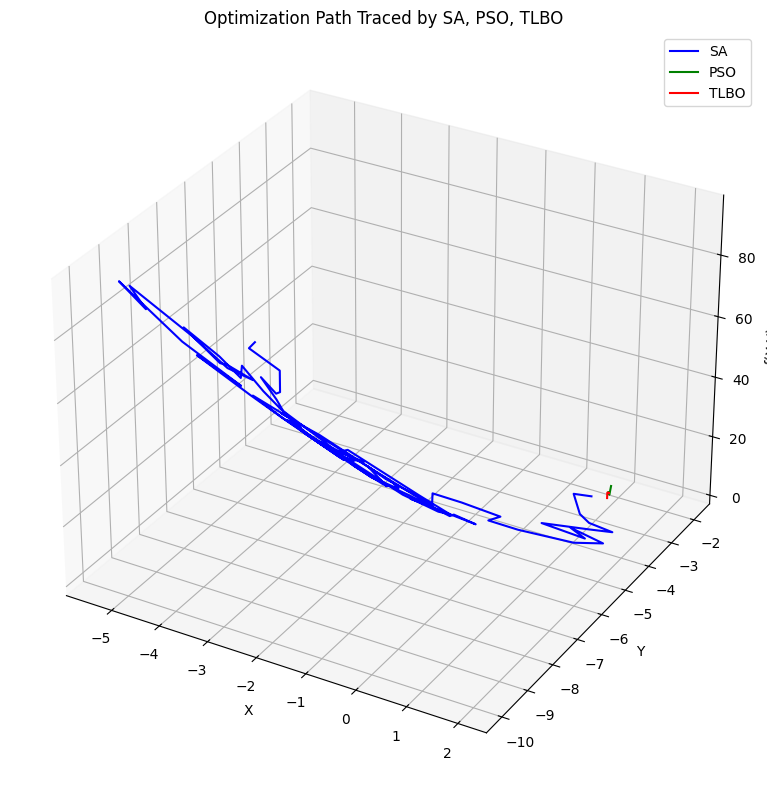

In [38]:
import random
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----- Simplified 2D Test Function -----
def simple_func_2d(xy):
    x, y = xy
    return (x - 1)**2 + (y + 2)**2 + math.sin(x + y)

# ----- Modified SA for Path -----
def SA_2D(func, bounds, max_iter=100, initial_temp=1000, cooling_rate=0.95):
    path = []

    def random_solution():
        return [random.uniform(low, high) for (low, high) in bounds]

    def neighbor(x):
        return [max(min(xi + random.uniform(-1, 1), bounds[i][1]), bounds[i][0])
                for i, xi in enumerate(x)]

    current = random_solution()
    current_eval = func(current)
    best = current[:]
    best_eval = current_eval
    temp = initial_temp

    for _ in range(max_iter):
        path.append((current[0], current[1], func(current)))
        candidate = neighbor(current)
        candidate_eval = func(candidate)
        delta = candidate_eval - current_eval
        if delta < 0 or math.exp(-delta / temp) > random.random():
            current, current_eval = candidate, candidate_eval
            if candidate_eval < best_eval:
                best, best_eval = candidate[:], candidate_eval
        temp *= cooling_rate
    return path

# ----- Modified PSO for Path -----
def PSO_2D(func, bounds, max_iter=100, pop_size=30):
    dim = len(bounds)
    swarm = [([random.uniform(low, high) for (low, high) in bounds], [0]*dim)
             for _ in range(pop_size)]
    personal_best = [(pos[:], func(pos)) for pos, _ in swarm]
    global_best = min(personal_best, key=lambda x: x[1])
    path = []

    for _ in range(max_iter):
        path.append((global_best[0][0], global_best[0][1], global_best[1]))
        for i, (position, velocity) in enumerate(swarm):
            for d in range(dim):
                r1, r2 = random.random(), random.random()
                velocity[d] = (
                    0.5 * velocity[d] +
                    1.5 * r1 * (personal_best[i][0][d] - position[d]) +
                    1.5 * r2 * (global_best[0][d] - position[d])
                )
                position[d] += velocity[d]
                position[d] = max(bounds[d][0], min(position[d], bounds[d][1]))
            value = func(position)
            if value < personal_best[i][1]:
                personal_best[i] = (position[:], value)
                if value < global_best[1]:
                    global_best = (position[:], value)
    return path

# ----- Modified TLBO for Path -----
def TLBO_2D(func, bounds, max_iter=100, pop_size=30):
    dim = len(bounds)
    population = [[random.uniform(low, high) for (low, high) in bounds]
                  for _ in range(pop_size)]
    path = []

    for _ in range(max_iter):
        fitness = [func(ind) for ind in population]
        teacher = population[fitness.index(min(fitness))]
        mean = [sum(x[i] for x in population) / pop_size for i in range(dim)]
        path.append((teacher[0], teacher[1], func(teacher)))

        # Teacher Phase
        for i in range(pop_size):
            TF = random.choice([1, 2])
            new_ind = [x + random.random() * (t - TF * m)
                       for x, t, m in zip(population[i], teacher, mean)]
            new_ind = [max(bounds[d][0], min(new_ind[d], bounds[d][1])) for d in range(dim)]
            if func(new_ind) < func(population[i]):
                population[i] = new_ind

        # Learner Phase
        for i in range(pop_size):
            j = random.choice([x for x in range(pop_size) if x != i])
            if func(population[i]) < func(population[j]):
                diff = [x1 - x2 for x1, x2 in zip(population[i], population[j])]
            else:
                diff = [x2 - x1 for x1, x2 in zip(population[i], population[j])]
            new_ind = [x + random.random() * d for x, d in zip(population[i], diff)]
            new_ind = [max(bounds[d][0], min(new_ind[d], bounds[d][1])) for d in range(dim)]
            if func(new_ind) < func(population[i]):
                population[i] = new_ind
    return path

# ----- Run All and Plot -----
bounds_2d = [(-10, 10), (-10, 10)]
sa_path = SA_2D(simple_func_2d, bounds_2d)
pso_path = PSO_2D(simple_func_2d, bounds_2d)
tlbo_path = TLBO_2D(simple_func_2d, bounds_2d)

def unpack(path): return zip(*path)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(*unpack(sa_path), label="SA", color='blue')
ax.plot(*unpack(pso_path), label="PSO", color='green')
ax.plot(*unpack(tlbo_path), label="TLBO", color='red')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(X,Y)')
ax.set_title('Optimization Path Traced by SA, PSO, TLBO')
ax.legend()
plt.tight_layout()
plt.show()


(-4.9165148321349905, -4.780329555723805, -4.34377301844125, -3.7926336377865217, -3.709360472928961, -4.096223104981922, -3.500555350789643, -3.0769719683696435, -2.570567265344486, -2.18395448153235, -1.6217183079613873, -2.1087088780793515, -1.2454982975541407, -0.668881340724373, 0.27124687756623267, 0.8042509383573415, 0.7810970974394214, -0.17210779703009993, 0.4649742803131134, -0.22681019641898348, -1.0011330425867453, -1.1723666554108179, -1.449809819205296, -1.7426898372612647, -1.4392008993014254, -2.305660712667078, -2.1725777938131126, -1.6680397744919204, -1.6304069812815256, -1.9277984648442315, -1.1353250915236182, -0.9856824585450814, -0.2782667127711509, -0.9558997778883862, -0.4530086293344444, 0.48179869445488777, 0.6559285165786184, 0.007413613993172419, -0.28344701788223037, -1.0694639306976566, -1.5760058135026098, -1.6804955057407893, -1.5464418055126905, -1.7581890999573973, -1.3478819900838286, -0.421975581810788, 0.016075106244364035, -0.05045391410511968, -0

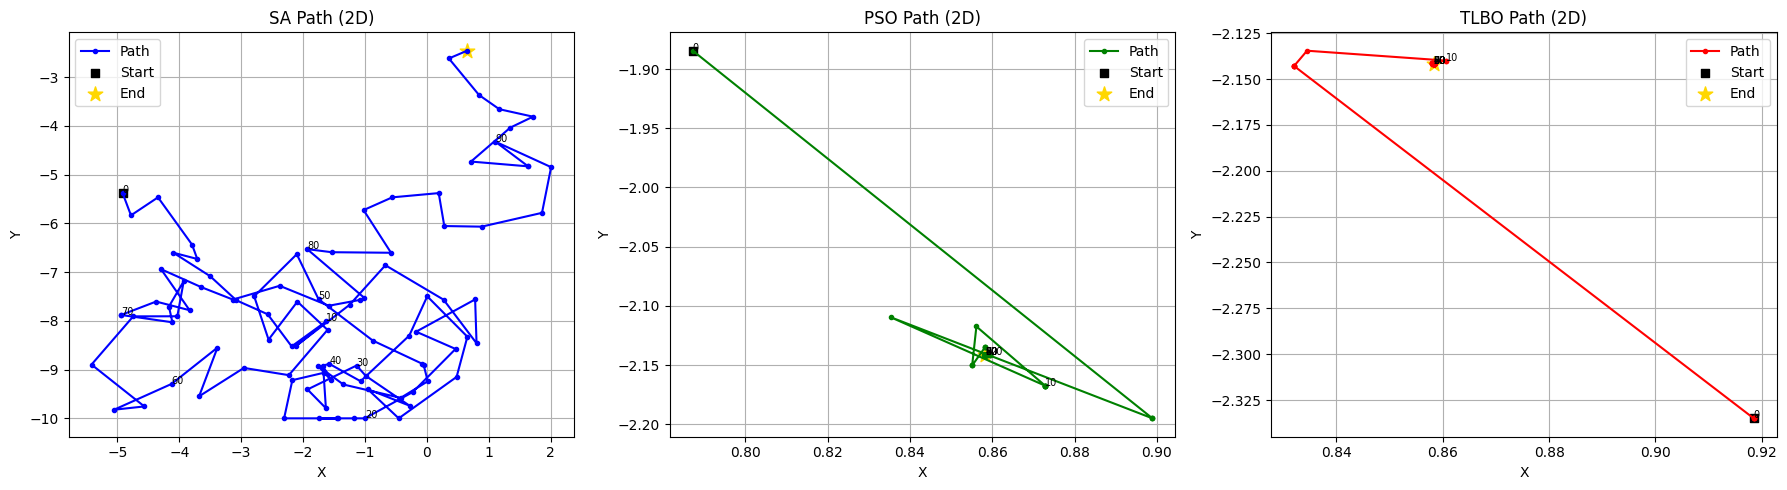

In [ ]:
import matplotlib.pyplot as plt

# Assuming you already have these from your optimizer runs:
# sa_path, pso_path, tlbo_path
# Each is a list of (x, y, f(x, y)) tuples

# Step 1: Convert to 2D projections
sa_path_2d = [(x, y) for x, y, _ in sa_path]
pso_path_2d = [(x, y) for x, y, _ in pso_path]
tlbo_path_2d = [(x, y) for x, y, _ in tlbo_path]

# Step 2: Plot function
def plot_2d_path(path, title, color):
    x_vals, y_vals = zip(*path)
    
    plt.plot(x_vals, y_vals, marker='o', markersize=3, linewidth=1.5, color=color, label='Path')
    
    # Mark start and end
    plt.scatter(x_vals[0], y_vals[0], color='black', marker='s', label='Start')
    plt.scatter(x_vals[-1], y_vals[-1], color='gold', marker='*', s=120, label='End')
    
    # Annotate every 10th step
    for i in range(0, len(path), max(len(path)//10, 1)):
        x, y = path[i]
        plt.text(x, y, f'{i}', fontsize=7)
        print(x_vals,y_vals)
    
        
    
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.legend()

# Step 3: Plot in separate subplots
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_2d_path(sa_path_2d, "SA Path (2D)", "blue")

plt.subplot(1, 3, 2)
plot_2d_path(pso_path_2d, "PSO Path (2D)", "green")

plt.subplot(1, 3, 3)
plot_2d_path(tlbo_path_2d, "TLBO Path (2D)", "red")

plt.tight_layout()
plt.show()
